In [41]:
%%capture
%run "./5.EDA_0_Cycle.ipynb"

In [42]:
print("Normal rows:", len(normal))
print("Normal segments:", normal["segment_id"].nunique())
print("AI2 missing:", normal["AI2_Current"].isna().sum())

display(
    normal[
        [
            "source_row",
            "elapsed_sec",
            "dt_sec",
            "segment_id",
            "AI2_Current",
        ]
    ].head()
)

Normal rows: 20000
Normal segments: 602
AI2 missing: 0


,source_row,elapsed_sec,dt_sec,segment_id,AI2_Current
0,0,0.0,NaN,0,192.338730
1,1,0.1,0.1,0,217.004330
2,2,0.2,0.1,0,197.510620
3,3,0.3,0.1,0,156.607170
4,4,0.4,0.1,0,93.236934


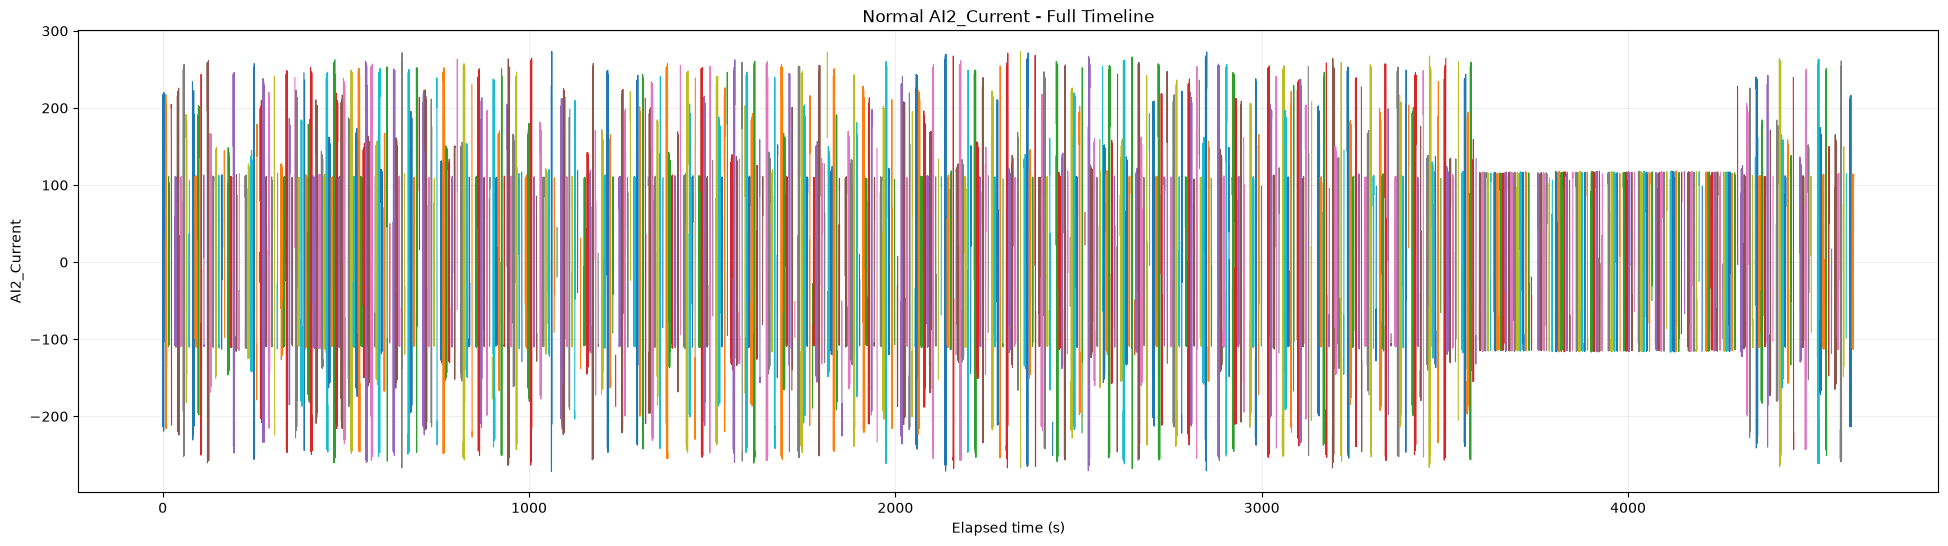

In [43]:
# 2만 행 전부 출력
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(24, 6))

for segment_id, group in normal.groupby("segment_id", sort=False):
    ax.plot(
        group["elapsed_sec"],
        group["AI2_Current"],
        linewidth=0.8
    )

ax.set_title("Normal AI2_Current - Full Timeline")
ax.set_xlabel("Elapsed time (s)")
ax.set_ylabel("AI2_Current")
ax.grid(alpha=0.2)

plt.show()


In [44]:
segment_info = (
    normal.groupby("segment_id")
    .agg(
        n_samples=("AI2_Current", "size"),
        start_time=("elapsed_sec", "min"),
        end_time=("elapsed_sec", "max"),
        ai2_min=("AI2_Current", "min"),
        ai2_max=("AI2_Current", "max"),
        ai2_mean=("AI2_Current", "mean"),
    )
)

segment_info["duration_sec"] = (
    segment_info["end_time"]
    - segment_info["start_time"]
)

display(segment_info.describe())

display(
    segment_info
    .sort_values("n_samples", ascending=False)
    .head(30)
)

,n_samples,start_time,end_time,ai2_min,ai2_max,ai2_mean,duration_sec
count,602.000000,602.000000,602.000000,602.000000,602.000000,602.000000,602.000000
mean,33.222591,2279.129236,2282.351495,-155.240337,158.157758,2.154085,3.222259
std,16.488799,1321.593736,1321.530255,70.156704,73.286257,36.592293,1.648880
min,1.000000,0.000000,4.000000,-271.568330,-207.819610,-235.937983,0.000000
25%,19.250000,1134.500000,1134.700000,-215.993127,112.956865,-2.893993,1.825000
50%,37.000000,2281.200000,2283.900000,-133.308185,138.622955,0.577363,3.600000
75%,50.000000,3398.800000,3399.750000,-111.100270,221.923142,6.539041,4.900000
max,50.000000,4611.500000,4615.800000,196.989320,273.235000,222.170143,4.900000


,n_samples,start_time,end_time,ai2_min,ai2_max,ai2_mean,duration_sec
segment_id,,,,,,,
10,50,81.2,86.1,-230.71566,233.89557,0.152128,4.9
11,50,87.9,92.8,-110.86966,112.13840,0.898716,4.9
590,50,4523.6,4528.5,-171.58594,174.58131,0.241523,4.9
595,50,4564.2,4569.1,-165.05673,165.36440,-0.325155,4.9
425,50,3193.1,3198.0,-267.03683,264.03085,0.120554,4.9
430,50,3233.3,3238.2,-254.28024,253.19925,0.259607,4.9
431,50,3240.0,3244.9,-184.83534,183.93805,1.166482,4.9
55,50,417.8,422.7,-209.12888,210.45914,0.862220,4.9
56,50,424.8,429.7,-112.28134,114.20239,0.185959,4.9


In [45]:
full_segments = segment_info.loc[
    segment_info["n_samples"] == 50
].index.tolist()

print(
    "50-sample Normal segments:",
    len(full_segments)
)

print(
    "First 30 IDs:",
    full_segments[:30]
)

50-sample Normal segments: 202
First 30 IDs: [4, 5, 6, 10, 11, 15, 16, 22, 23, 27, 28, 33, 34, 41, 42, 47, 48, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63]


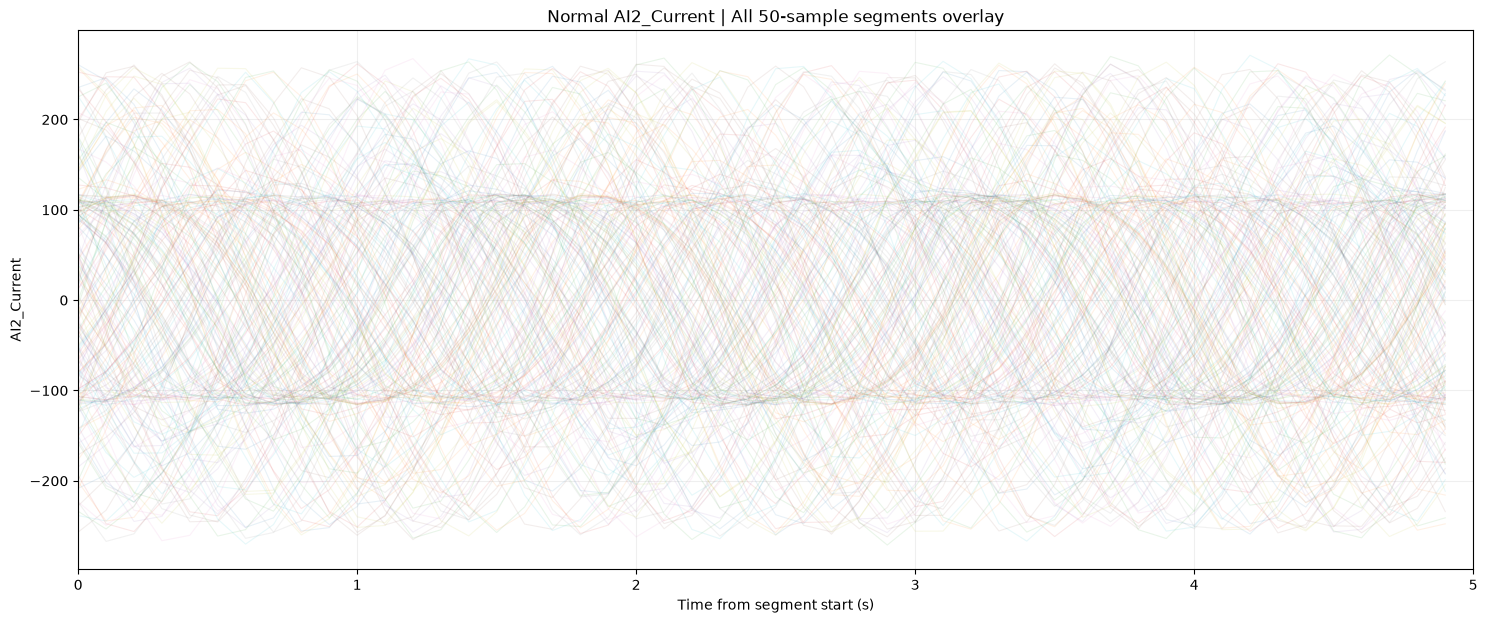

In [46]:
fig, ax = plt.subplots(figsize=(18, 7))

for segment_id in full_segments:

    group = (
        normal.loc[
            normal["segment_id"] == segment_id
        ]
        .copy()
    )

    local_time = (
        group["elapsed_sec"]
        - group["elapsed_sec"].iloc[0]
    )

    ax.plot(
        local_time,
        group["AI2_Current"],
        alpha=0.10,
        linewidth=0.8
    )

ax.set_title(
    "Normal AI2_Current | "
    "All 50-sample segments overlay"
)

ax.set_xlabel(
    "Time from segment start (s)"
)

ax.set_ylabel(
    "AI2_Current"
)

ax.set_xlim(0, 5)

ax.grid(alpha=0.2)

plt.show()

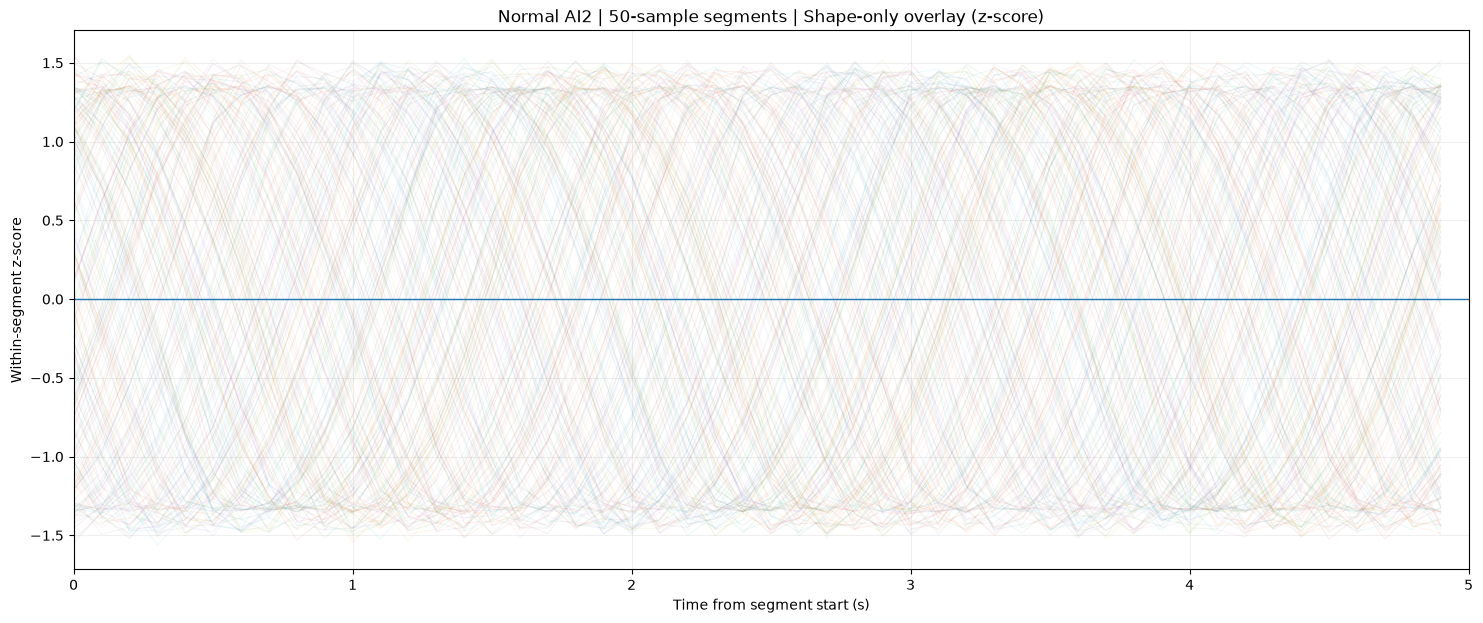

In [47]:
# 7. 각 segemnt 를 정규화해서 shape 비교

fig, ax = plt.subplots(figsize=(18, 7))

for segment_id in full_segments:

    group = (
        normal.loc[
            normal["segment_id"] == segment_id
        ]
        .copy()
    )

    x = group[
        "AI2_Current"
    ].to_numpy(dtype=float)

    std = np.std(x)

    if std == 0:
        continue

    z = (
        x - np.mean(x)
    ) / std

    local_time = np.arange(
        len(x)
    ) / SAMPLE_RATE_HZ

    ax.plot(
        local_time,
        z,
        alpha=0.08,
        linewidth=0.8
    )

ax.set_title(
    "Normal AI2 | "
    "50-sample segments | "
    "Shape-only overlay (z-score)"
)

ax.set_xlabel(
    "Time from segment start (s)"
)

ax.set_ylabel(
    "Within-segment z-score"
)

ax.set_xlim(0, 5)

ax.axhline(
    0,
    linewidth=1
)

ax.grid(alpha=0.2)

plt.show()

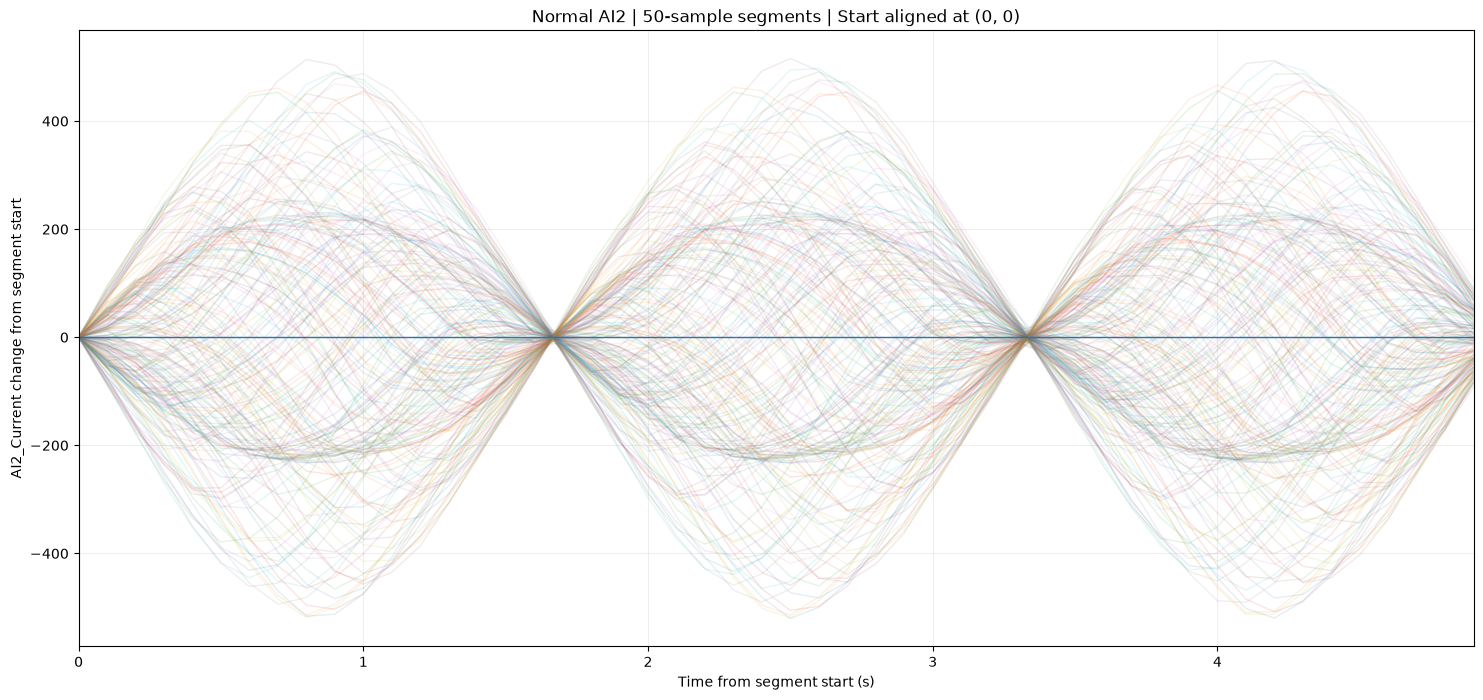

In [48]:
fig, ax = plt.subplots(figsize=(18, 8))

for segment_id in full_segments:

    group = (
        normal.loc[
            normal["segment_id"] == segment_id
        ]
        .sort_values("elapsed_sec")
        .copy()
    )

    # X축: 각 segment 시작시간을 0초로 이동
    x = (
        group["elapsed_sec"].to_numpy()
        - group["elapsed_sec"].iloc[0]
    )

    # Y축: 각 segment 첫 AI2 값을 0으로 이동
    y = group["AI2_Current"].to_numpy(dtype=float)
    y_shifted = y - y[0]

    ax.plot(
        x,
        y_shifted,
        alpha=0.12,
        linewidth=1.0
    )

ax.axhline(0, linewidth=1)

ax.set_title(
    "Normal AI2 | 50-sample segments | Start aligned at (0, 0)"
)

ax.set_xlabel("Time from segment start (s)")
ax.set_ylabel("AI2_Current change from segment start")

ax.set_xlim(0, 4.9)

ax.grid(alpha=0.2)

plt.show()

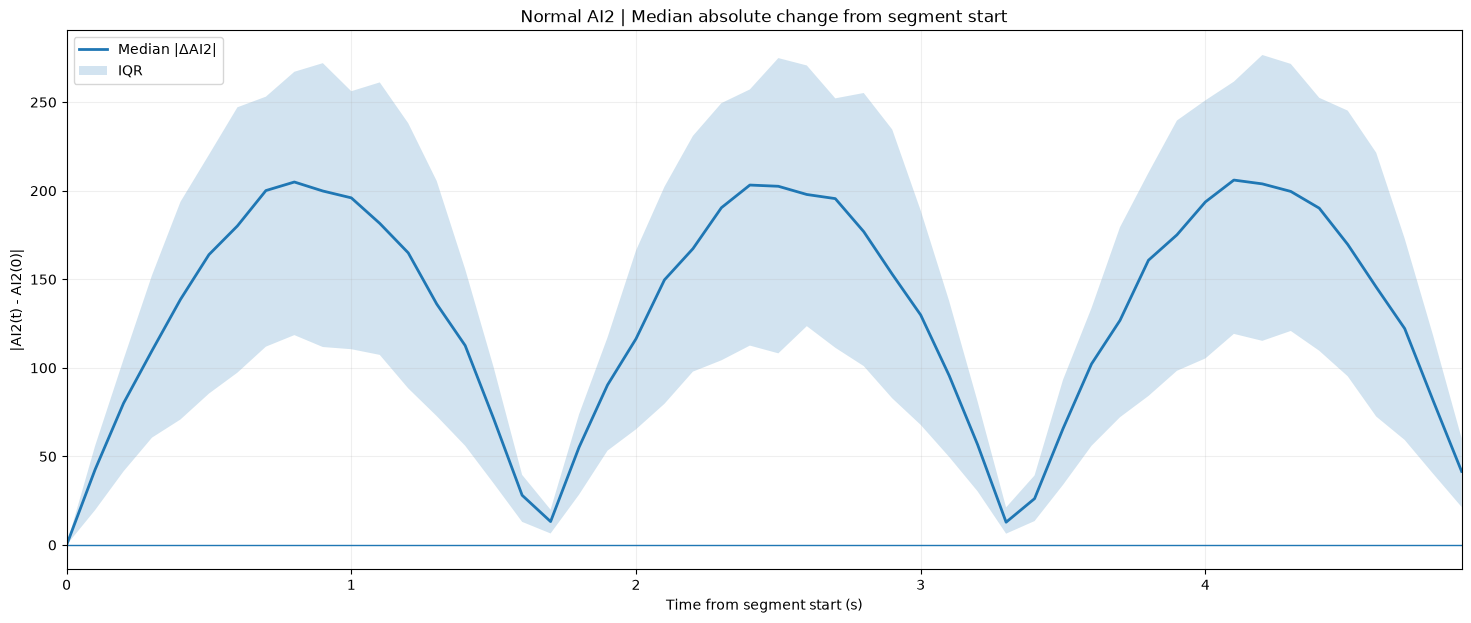

In [49]:
fig, ax = plt.subplots(figsize=(18, 7))

aligned_abs = []

for segment_id in full_segments:

    group = (
        normal.loc[
            normal["segment_id"] == segment_id
        ]
        .sort_values("elapsed_sec")
    )

    y = group["AI2_Current"].to_numpy(dtype=float)

    # 시작값을 0으로 이동
    y_shifted = y - y[0]

    # 상승/하강 방향을 제거하고 변화량 크기만 확인
    aligned_abs.append(np.abs(y_shifted))


aligned_abs = np.vstack(aligned_abs)

median_abs = np.median(aligned_abs, axis=0)

q25 = np.quantile(aligned_abs, 0.25, axis=0)
q75 = np.quantile(aligned_abs, 0.75, axis=0)

time = np.arange(aligned_abs.shape[1]) / SAMPLE_RATE_HZ


ax.plot(
    time,
    median_abs,
    linewidth=2,
    label="Median |ΔAI2|"
)

ax.fill_between(
    time,
    q25,
    q75,
    alpha=0.2,
    label="IQR"
)

ax.axhline(0, linewidth=1)

ax.set_title(
    "Normal AI2 | Median absolute change from segment start"
)

ax.set_xlabel("Time from segment start (s)")
ax.set_ylabel("|AI2(t) - AI2(0)|")

ax.set_xlim(0, 4.9)

ax.grid(alpha=0.2)
ax.legend()

plt.show()

In [50]:
up_segments = []
down_segments = []

CHECK_SAMPLE = 8   # 약 0.8초

for segment_id in full_segments:

    group = (
        normal.loc[
            normal["segment_id"] == segment_id
        ]
        .sort_values("elapsed_sec")
    )

    y = group["AI2_Current"].to_numpy(dtype=float)
    y_shifted = y - y[0]

    if y_shifted[CHECK_SAMPLE] >= 0:
        up_segments.append(segment_id)
    else:
        down_segments.append(segment_id)

print("Up-type segments:", len(up_segments))
print("Down-type segments:", len(down_segments))

Up-type segments: 97
Down-type segments: 105


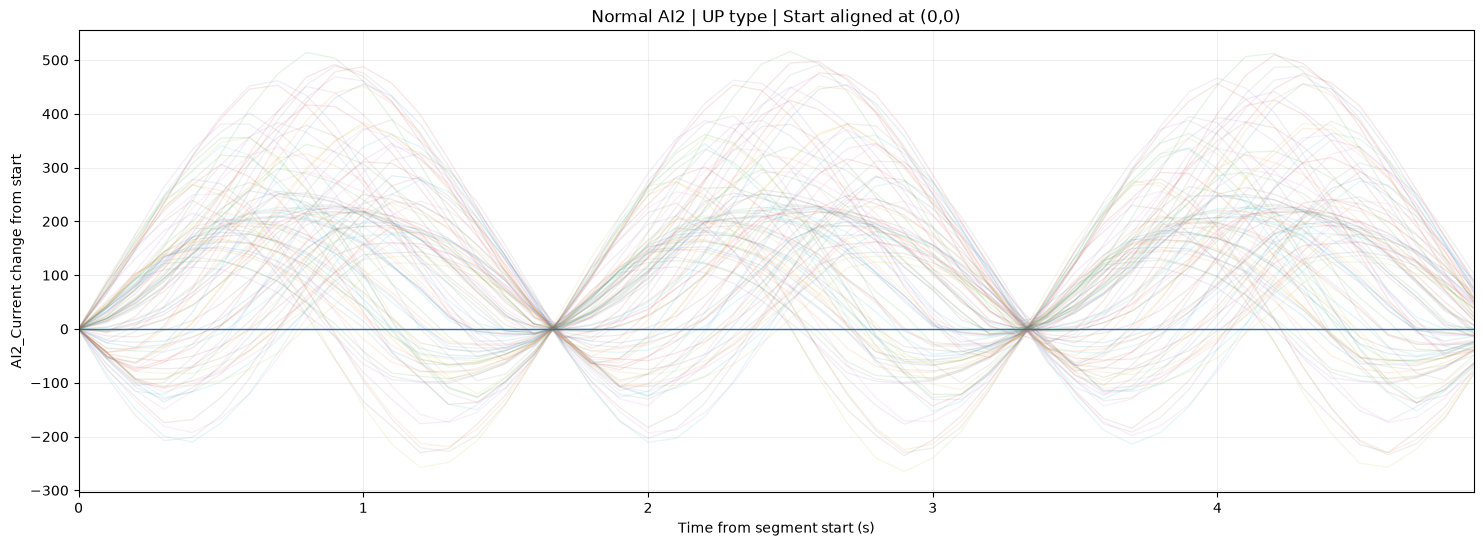

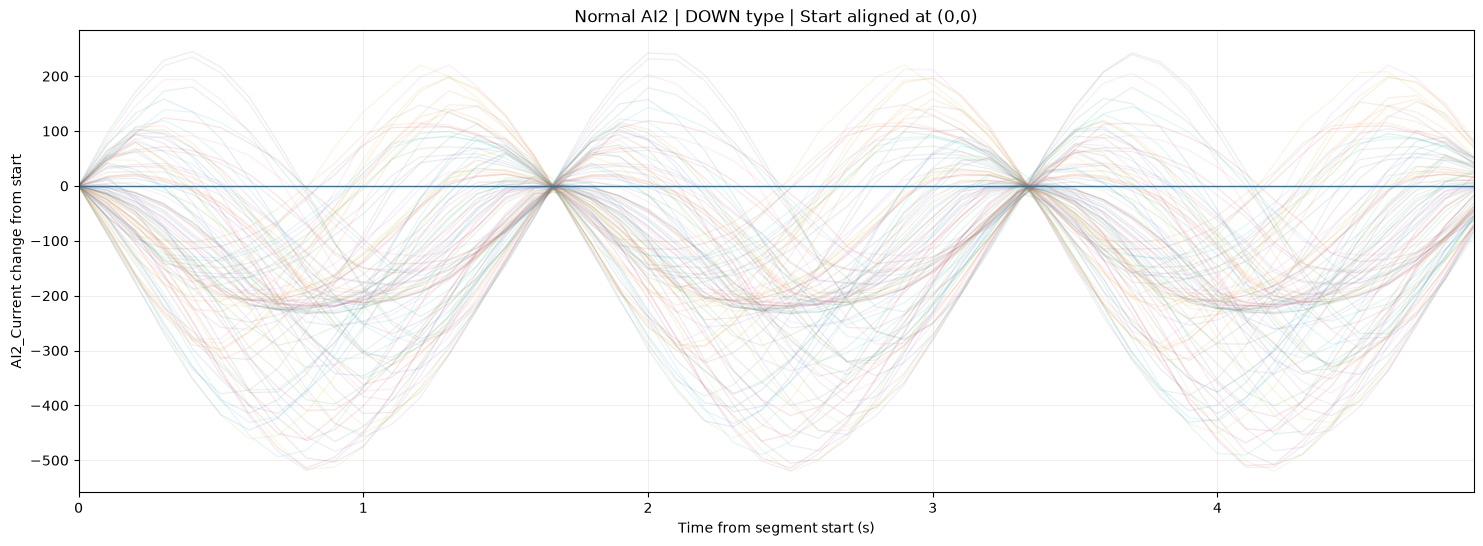

In [51]:
for name, segment_ids in [
    ("UP type", up_segments),
    ("DOWN type", down_segments),
]:

    fig, ax = plt.subplots(figsize=(18, 6))

    for segment_id in segment_ids:

        group = (
            normal.loc[
                normal["segment_id"] == segment_id
            ]
            .sort_values("elapsed_sec")
        )

        y = group["AI2_Current"].to_numpy(dtype=float)
        y_shifted = y - y[0]

        time = np.arange(len(y)) / SAMPLE_RATE_HZ

        ax.plot(
            time,
            y_shifted,
            alpha=0.12,
            linewidth=0.9
        )

    ax.axhline(0, linewidth=1)

    ax.set_title(
        f"Normal AI2 | {name} | Start aligned at (0,0)"
    )

    ax.set_xlabel("Time from segment start (s)")
    ax.set_ylabel("AI2_Current change from start")
    ax.set_xlim(0, 4.9)
    ax.grid(alpha=0.2)

    plt.show()

마크다운
50행 미만 normal segment 원본값 분석

Short Normal segments: 400


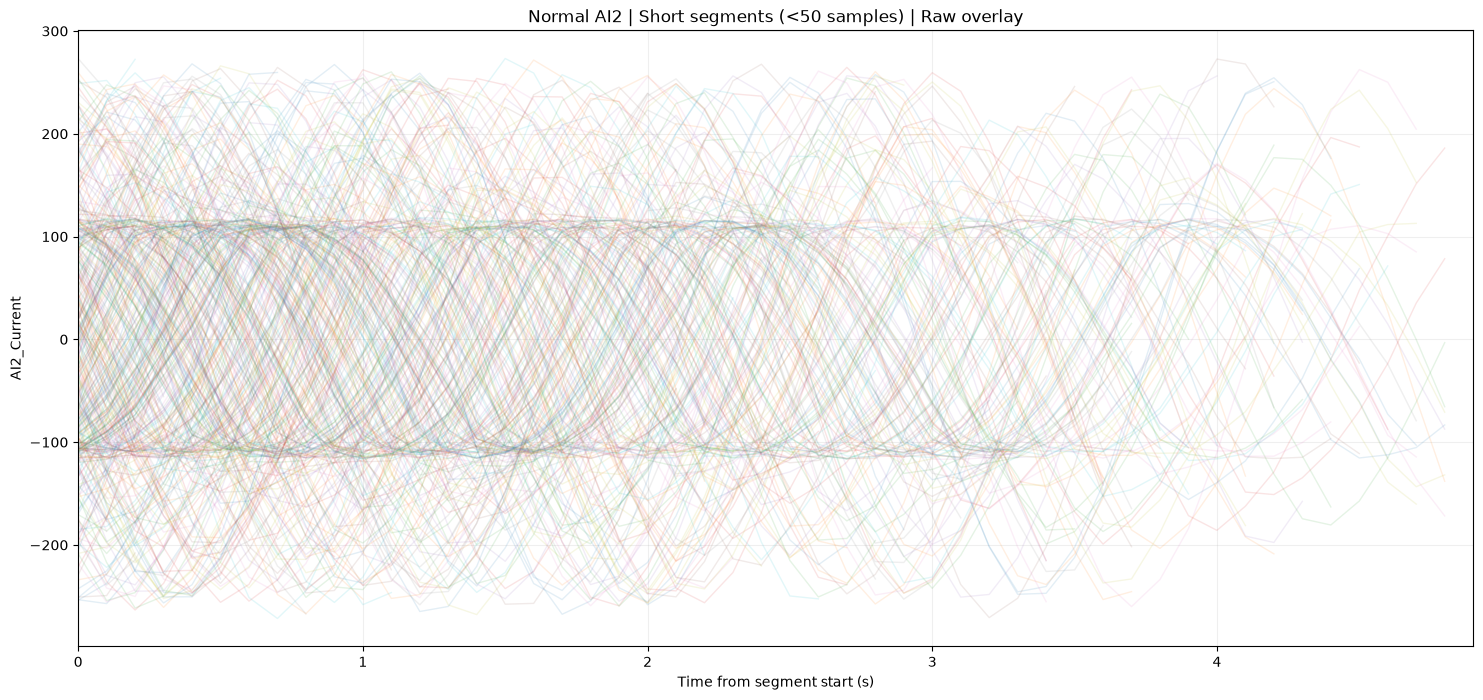

In [52]:
# 50 samples 미만의 Normal segment
short_segments = segment_info.loc[
    segment_info["n_samples"] < 50
].index.tolist()

print("Short Normal segments:", len(short_segments))

fig, ax = plt.subplots(figsize=(18, 8))

for segment_id in short_segments:

    group = (
        normal.loc[
            normal["segment_id"] == segment_id
        ]
        .sort_values("elapsed_sec")
        .copy()
    )

    # x축만 각 segment 내부 시간으로 변환
    # y축 AI2 값은 그대로 유지
    local_time = (
        group["elapsed_sec"]
        - group["elapsed_sec"].iloc[0]
    )

    ax.plot(
        local_time,
        group["AI2_Current"],
        alpha=0.12,
        linewidth=1.0
    )

ax.set_title(
    "Normal AI2 | Short segments (<50 samples) | Raw overlay"
)

ax.set_xlabel("Time from segment start (s)")
ax.set_ylabel("AI2_Current")

ax.set_xlim(0, 4.9)

ax.grid(alpha=0.2)

plt.show()

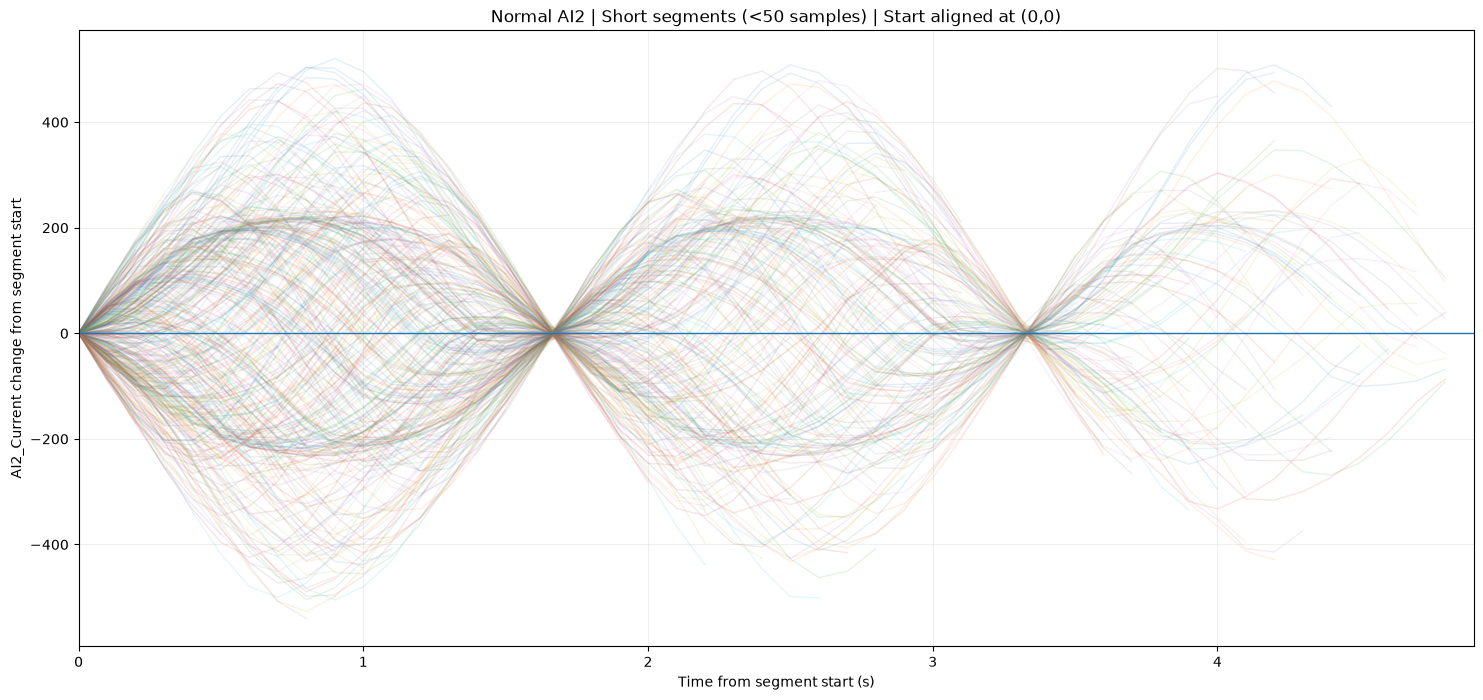

In [53]:
fig, ax = plt.subplots(figsize=(18, 8))

for segment_id in short_segments:

    group = (
        normal.loc[
            normal["segment_id"] == segment_id
        ]
        .sort_values("elapsed_sec")
        .copy()
    )

    # 각 segment 내부 시간
    x = (
        group["elapsed_sec"].to_numpy(dtype=float)
        - group["elapsed_sec"].iloc[0]
    )

    # 시작 AI2 값을 0으로 평행이동
    y = group["AI2_Current"].to_numpy(dtype=float)
    y_shifted = y - y[0]

    ax.plot(
        x,
        y_shifted,
        alpha=0.12,
        linewidth=1.0
    )

ax.axhline(0, linewidth=1)

ax.set_title(
    "Normal AI2 | Short segments (<50 samples) | Start aligned at (0,0)"
)

ax.set_xlabel("Time from segment start (s)")
ax.set_ylabel("AI2_Current change from segment start")

ax.set_xlim(0, 4.9)
ax.grid(alpha=0.2)

plt.show()


In [54]:
# 1. 각 Normal segment별 반복주기 추정
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 현재 데이터는 약 10 Hz
SAMPLE_INTERVAL = 0.1

# 우리가 육안으로 확인한 반복주기 주변을 넉넉하게 탐색
MIN_PERIOD_SEC = 1.2
MAX_PERIOD_SEC = 2.2

min_lag = int(MIN_PERIOD_SEC / SAMPLE_INTERVAL)
max_lag = int(MAX_PERIOD_SEC / SAMPLE_INTERVAL)


def estimate_period_acf(group):

    y = (
        group
        .sort_values("elapsed_sec")["AI2_Current"]
        .to_numpy(dtype=float)
    )

    # 너무 짧으면 1.2~2.2초 반복을 판단하기 어려움
    if len(y) <= max_lag:
        return np.nan, np.nan

    # 평균 제거
    y = y - np.mean(y)

    # 신호 변화가 거의 없는 경우 제외
    if np.std(y) == 0:
        return np.nan, np.nan

    acf_values = []

    for lag in range(min_lag, max_lag + 1):

        x1 = y[:-lag]
        x2 = y[lag:]

        # 비교 가능한 값이 너무 적으면 제외
        if len(x1) < 5:
            acf_values.append(np.nan)
            continue

        if np.std(x1) == 0 or np.std(x2) == 0:
            acf_values.append(np.nan)
            continue

        corr = np.corrcoef(x1, x2)[0, 1]

        acf_values.append(corr)

    acf_values = np.array(acf_values)

    if np.all(np.isnan(acf_values)):
        return np.nan, np.nan

    best_idx = np.nanargmax(acf_values)

    best_lag = min_lag + best_idx
    best_corr = acf_values[best_idx]

    period_sec = best_lag * SAMPLE_INTERVAL

    return period_sec, best_corr

In [55]:
# 모든 정상 segment에 적용
period_results = []

for segment_id, group in normal.groupby("segment_id"):

    period_sec, acf_corr = estimate_period_acf(group)

    period_results.append({
        "segment_id": segment_id,
        "n_samples": len(group),
        "period_sec": period_sec,
        "acf_corr": acf_corr
    })


period_df = pd.DataFrame(period_results)

display(period_df.head())

print(
    "전체 Normal segments:",
    normal["segment_id"].nunique()
)

print(
    "주기 계산 가능 segments:",
    period_df["period_sec"].notna().sum()
)

,segment_id,n_samples,period_sec,acf_corr
0,0,41,1.7,0.991380
1,1,37,1.7,0.993755
2,2,24,1.7,0.997951
3,3,10,NaN,NaN
4,4,50,1.7,0.992062


전체 Normal segments: 602
주기 계산 가능 segments: 423


In [56]:
# 반복주기 숫자 요약
valid_period = period_df.dropna(
    subset=["period_sec"]
)

print("=== Normal AI2 반복주기 요약 ===")

print(
    valid_period["period_sec"].describe()
)

print()

print(
    "Median period:",
    valid_period["period_sec"].median(),
    "sec"
)

print(
    "Mean period:",
    valid_period["period_sec"].mean(),
    "sec"
)

print(
    "Std period:",
    valid_period["period_sec"].std(),
    "sec"
)

print(
    "Median ACF correlation:",
    valid_period["acf_corr"].median()
)

=== Normal AI2 반복주기 요약 ===
count    423.000000
mean       1.699527
std        0.006868
min        1.600000
25%        1.700000
50%        1.700000
75%        1.700000
max        1.700000
Name: period_sec, dtype: float64

Median period: 1.7000000000000002 sec
Mean period: 1.6995271867612287 sec
Std period: 0.006867989722271522 sec
Median ACF correlation: 0.9918689192304082


In [57]:
# 각 주기가 어디에 몰려 있는지 확인
period_counts = (
    valid_period["period_sec"]
    .value_counts()
    .sort_index()
)

display(
    period_counts.rename("segment_count")
)

period_sec
1.6      2
1.7    421
Name: segment_count, dtype: int64

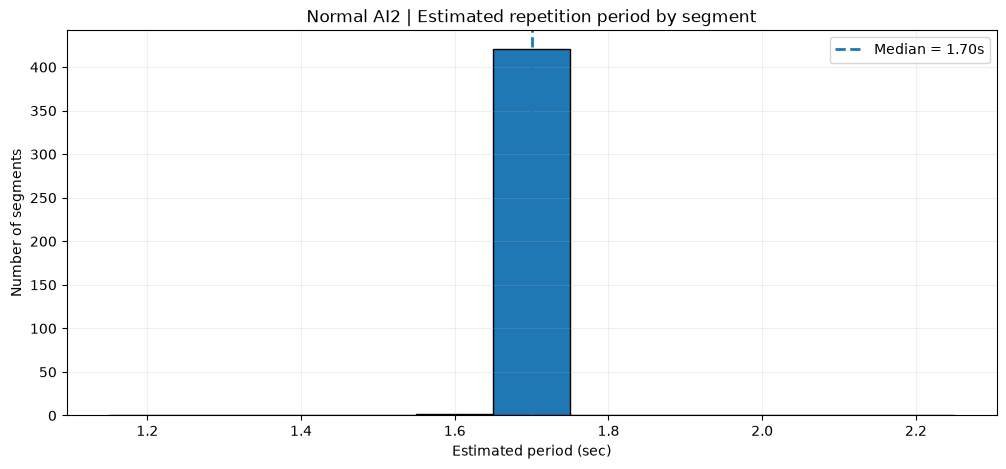

In [58]:
fig, ax = plt.subplots(figsize=(12, 5))

bins = np.arange(
    1.15,
    2.26,
    0.1
)

ax.hist(
    valid_period["period_sec"],
    bins=bins,
    edgecolor="black"
)

ax.axvline(
    valid_period["period_sec"].median(),
    linestyle="--",
    linewidth=2,
    label=f'Median = {valid_period["period_sec"].median():.2f}s'
)

ax.set_title(
    "Normal AI2 | Estimated repetition period by segment"
)

ax.set_xlabel("Estimated period (sec)")
ax.set_ylabel("Number of segments")

ax.legend()
ax.grid(alpha=0.2)

plt.show()

In [60]:
period_rounded = valid_period["period_sec"].round(1)

target_mask = period_rounded.between(
    1.6,
    1.7,
    inclusive="both"
)

target_count = int(target_mask.sum())
total_count = len(valid_period)

ratio = (
    target_count
    / total_count
    * 100
)

print(
    f"1.6~1.7 sec segments: "
    f"{target_count} / {total_count}"
)

print(
    f"Ratio: {ratio:.1f}%"
)

1.6~1.7 sec segments: 423 / 423
Ratio: 100.0%


# 마지막 검증 : segment 시작 위상 검증
# Gap 뒤에서 시작하는 각 Normal segment의 첫 지점이 AI2 
# 반복파형의 랜덤한 위치인지, 아니면 비슷한 위상에 정렬되어 있는지 확인한다

## ② Segment 시작 위상 검증

### 목적

Normal AI2_Current의 각 segment는 Gap 이후 서로 다른 시점에서 시작하지만,
시작점을 기준으로 정렬했을 때 약 1.7초 반복 파형이 강하게 정렬되는 현상이 관찰되었다.

따라서 각 segment의 시작점이 반복 파형의 임의 위치인지,
아니면 유사한 위상에 정렬되는 경향이 있는지 검증한다.

※ Segment 시작점을 실제 공정 시작점으로 가정하지 않는다.
※ Gap 발생 원인의 물리적 의미는 본 단계에서 판단하지 않는다.

In [61]:
PHASE_PERIOD_SAMPLES = 17   # 10 Hz 기준 약 1.7초

phase_results = []

for segment_id, group in normal.groupby("segment_id", sort=False):

    group = (
        group
        .sort_values("elapsed_sec")
        .copy()
    )

    y = group["AI2_Current"].to_numpy(dtype=float)

    # 시작점 + 17 samples까지 존재해야 비교 가능
    if len(y) <= PHASE_PERIOD_SAMPLES:
        continue

    start_value = y[0]
    value_17 = y[PHASE_PERIOD_SAMPLES]

    delta_17 = value_17 - start_value

    # segment 내부 변동 크기
    signal_range = np.ptp(y)

    # 서로 다른 amplitude의 segment를 비교하기 위한 정규화 오차
    if signal_range > 0:
        normalized_return_error = (
            abs(delta_17) / signal_range
        )
    else:
        normalized_return_error = np.nan

    phase_results.append({
        "segment_id": segment_id,
        "n_samples": len(y),
        "start_value": start_value,
        "value_1_7s": value_17,
        "delta_1_7s": delta_17,
        "abs_delta_1_7s": abs(delta_17),
        "signal_range": signal_range,
        "normalized_return_error": normalized_return_error
    })


phase_df = pd.DataFrame(phase_results)

print(
    "Comparable segments:",
    len(phase_df)
)

display(phase_df.head())

Comparable segments: 462


,segment_id,n_samples,start_value,value_1_7s,delta_1_7s,abs_delta_1_7s,signal_range,normalized_return_error
0,0,41,192.338730,208.763390,16.424660,16.424660,439.24885,0.037393
1,1,37,28.972868,9.004713,-19.968155,19.968155,433.55648,0.046057
2,2,24,-109.878910,-107.645170,2.233740,2.233740,220.65249,0.010123
3,4,50,58.613784,45.624619,-12.989165,12.989165,221.60950,0.058613
4,5,50,106.054200,128.975880,22.921680,22.921680,449.98281,0.050939


In [62]:
print("=== 1.7 sec Return-to-start Test ===")

display(
    phase_df[
        [
            "abs_delta_1_7s",
            "normalized_return_error"
        ]
    ].describe()
)

print(
    "Median absolute return error:",
    phase_df["abs_delta_1_7s"].median()
)

print(
    "Median normalized return error:",
    phase_df["normalized_return_error"].median()
)

=== 1.7 sec Return-to-start Test ===


,abs_delta_1_7s,normalized_return_error
count,462.000000,462.000000
mean,13.468406,0.039450
std,8.572167,0.021764
min,0.046140,0.000204
25%,6.271038,0.023384
50%,12.735547,0.039103
75%,19.176191,0.054981
max,36.913161,0.101783


Median absolute return error: 12.735547000000004
Median normalized return error: 0.03910334100841595


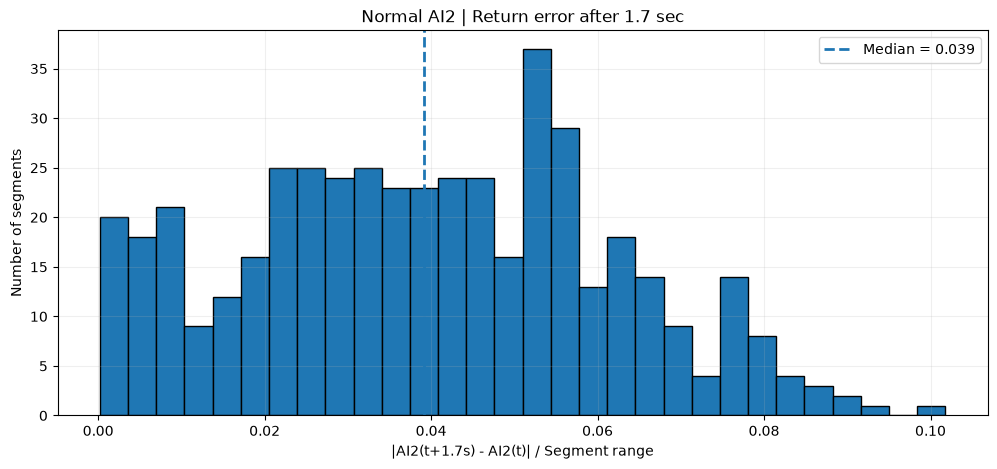

In [63]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(
    phase_df["normalized_return_error"].dropna(),
    bins=30,
    edgecolor="black"
)

median_error = (
    phase_df["normalized_return_error"]
    .median()
)

ax.axvline(
    median_error,
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_error:.3f}"
)

ax.set_title(
    "Normal AI2 | Return error after 1.7 sec"
)

ax.set_xlabel(
    "|AI2(t+1.7s) - AI2(t)| / Segment range"
)

ax.set_ylabel("Number of segments")

ax.grid(alpha=0.2)
ax.legend()

plt.show()

In [64]:
TEST_LAGS = [
    5,   # 0.5 sec
    8,   # 0.8 sec
    10,  # 1.0 sec
    17,  # 1.7 sec
    20,  # 2.0 sec
]

lag_results = []

for lag in TEST_LAGS:

    errors = []

    for segment_id, group in normal.groupby(
        "segment_id",
        sort=False
    ):

        group = group.sort_values("elapsed_sec")

        y = group["AI2_Current"].to_numpy(dtype=float)

        if len(y) <= lag:
            continue

        signal_range = np.ptp(y)

        if signal_range == 0:
            continue

        error = (
            abs(y[lag] - y[0])
            / signal_range
        )

        errors.append(error)

    lag_results.append({
        "lag_samples": lag,
        "lag_sec": lag / SAMPLE_RATE_HZ,
        "n_segments": len(errors),
        "median_return_error": np.median(errors),
        "q25_return_error": np.quantile(errors, 0.25),
        "q75_return_error": np.quantile(errors, 0.75),
    })


lag_df = pd.DataFrame(lag_results)

display(lag_df)

,lag_samples,lag_sec,n_segments,median_return_error,q25_return_error,q75_return_error
0,5,0.5,566,0.576663,0.310581,0.746255
1,8,0.8,539,0.708129,0.368545,0.925239
2,10,1.0,522,0.670734,0.369806,0.865569
3,17,1.7,462,0.039103,0.023384,0.054981
4,20,2.0,443,0.406514,0.216458,0.516224


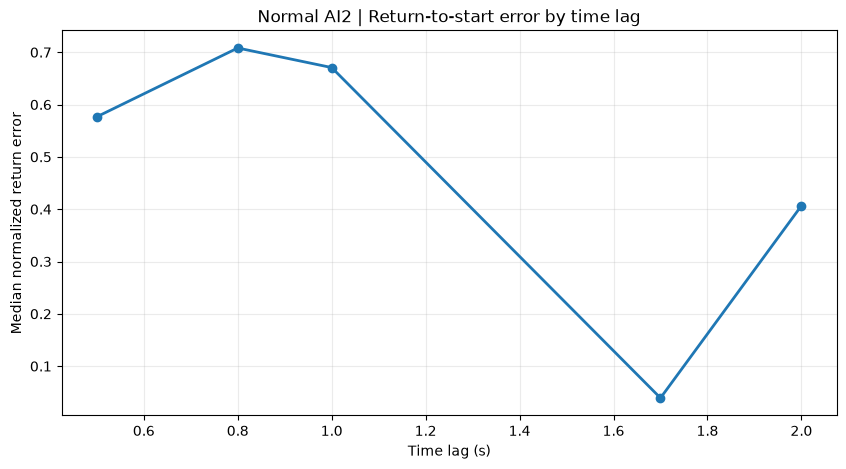

In [65]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    lag_df["lag_sec"],
    lag_df["median_return_error"],
    marker="o",
    linewidth=2
)

ax.set_title(
    "Normal AI2 | Return-to-start error by time lag"
)

ax.set_xlabel("Time lag (s)")
ax.set_ylabel("Median normalized return error")

ax.grid(alpha=0.25)

plt.show()